# NB06: Synthesis — Contamination Plume Model

**Goal**: Integrate all findings (NB02-NB05) under a contamination plume framework and produce a summary figure.

## Hydrogeological Context

The SSO sits **downhill and southwest** of a contamination source at Oak Ridge Area 3. The source delivers:
- **High nitrate** (the dominant electron acceptor in the plume)
- **Low pH** (acid conditions from nitric acid processing)
- **Heavy metals** (uranium, chromium, nickel, etc.)

The plume enters the SSO grid from the **northeast** (upper-east corner, near U3) and flows toward the **southwest** (lower-west, near L7). This reframes every finding from NB02-NB05.

In [1]:
import pandas as pd
import numpy as np
from pathlib import Path
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.patches import FancyArrowPatch
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

DATA = Path('../data')
FIG = Path('../figures')

GRID = {
    'SSO-U1': (2, 0), 'SSO-U2': (2, 1), 'SSO-U3': (2, 2),
    'SSO-M4': (1, 0), 'SSO-M5': (1, 1), 'SSO-M6': (1, 2),
    'SSO-L7': (0, 0), 'SSO-L8': (0, 1), 'SSO-L9': (0, 2),
}
WELL_ORDER = ['SSO-U1', 'SSO-U2', 'SSO-U3', 'SSO-M4', 'SSO-M5', 'SSO-M6',
              'SSO-L7', 'SSO-L8', 'SSO-L9']

# Load all results
process_pct = pd.read_csv(DATA / 'genus_function_grid.csv', index_col=0)
class_traits = pd.read_csv(DATA / 'trait_profiles_class.csv', index_col=0)
bc_matrix = pd.read_csv(DATA / 'bc_dissimilarity_sediment.csv', index_col=0)
spatial_stats = pd.read_csv(DATA / 'spatial_stats.csv')

print("All data loaded")

All data loaded


## 1. Synthesis Figure: Plume Model Overlaid on SSO Grid

The key summary figure maps the contamination plume trajectory, the redox zonation inferred from microbiology, and the key process hotspots onto the physical grid.

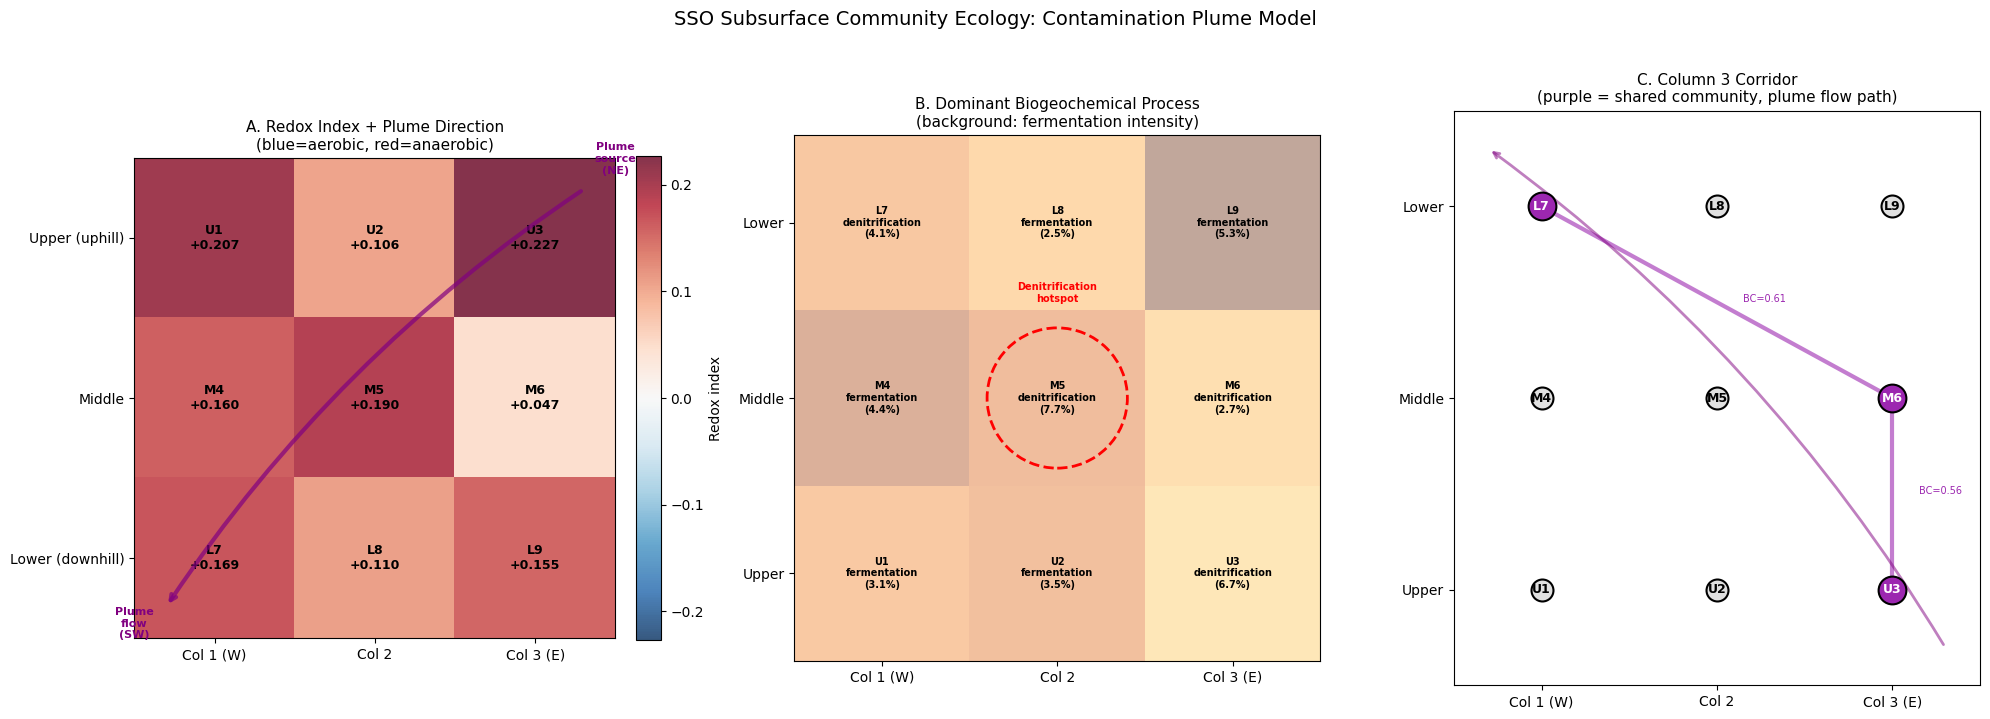

Saved: figures/synthesis_plume_model.png


In [2]:
# ============================================================
# SYNTHESIS FIGURE: Contamination Plume Model on SSO Grid
# ============================================================
fig, axes = plt.subplots(1, 3, figsize=(20, 7))

# --- Panel A: Redox environment + plume arrow ---
ax = axes[0]
redox = class_traits['redox_index'] if 'redox_index' in class_traits.columns else class_traits['aerobic'] - class_traits['anaerobic']

grid_vals = np.full((3, 3), np.nan)
for well in WELL_ORDER:
    r, c = GRID[well]
    grid_vals[2-r, c] = redox[well]

vlim = max(abs(np.nanmin(grid_vals)), abs(np.nanmax(grid_vals)))
im = ax.imshow(grid_vals, cmap='RdBu_r', vmin=-vlim, vmax=vlim, aspect='equal', alpha=0.8)

for well in WELL_ORDER:
    r, c = GRID[well]
    val = redox[well]
    label = f"{well.replace('SSO-','')}\n{val:+.3f}"
    ax.text(c, 2-r, label, ha='center', va='center', fontsize=9, fontweight='bold')

# Plume arrow: from NE (U3=col2,row0) toward SW (L7=col0,row2)
ax.annotate('', xy=(-0.3, 2.3), xytext=(2.3, -0.3),
            arrowprops=dict(arrowstyle='->', color='purple', lw=3, alpha=0.7,
                           connectionstyle='arc3,rad=0.1'))
ax.text(2.5, -0.4, 'Plume\nsource\n(NE)', fontsize=8, color='purple', 
        ha='center', fontweight='bold')
ax.text(-0.5, 2.5, 'Plume\nflow\n(SW)', fontsize=8, color='purple',
        ha='center', fontweight='bold')

ax.set_xticks([0,1,2]); ax.set_xticklabels(['Col 1 (W)', 'Col 2', 'Col 3 (E)'])
ax.set_yticks([0,1,2]); ax.set_yticklabels(['Upper (uphill)', 'Middle', 'Lower (downhill)'])
ax.set_title('A. Redox Index + Plume Direction\n(blue=aerobic, red=anaerobic)', fontsize=11)
plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04, label='Redox index')

# --- Panel B: Key process hotspots ---
ax = axes[1]

# Background: fermentation intensity (anaerobic indicator)
ferm_grid = np.full((3, 3), np.nan)
for well in WELL_ORDER:
    r, c = GRID[well]
    ferm_grid[2-r, c] = process_pct.loc[well, 'fermentation']
ax.imshow(ferm_grid, cmap='YlOrBr', vmin=0, vmax=ferm_grid[~np.isnan(ferm_grid)].max(),
          aspect='equal', alpha=0.4)

# Annotate each well with its dominant process
dominant_processes = {}
for well in WELL_ORDER:
    procs = process_pct.loc[well].drop(['aerobic_C_degrad', 'organohalide_resp'], errors='ignore')
    top_proc = procs.idxmax()
    top_val = procs.max()
    dominant_processes[well] = (top_proc, top_val)

for well in WELL_ORDER:
    r, c = GRID[well]
    proc, val = dominant_processes[well]
    short_name = well.replace('SSO-', '')
    proc_short = proc.replace('_', '\n').replace('reduction', 'red.').replace('oxidation', 'ox.')
    ax.text(c, 2-r, f"{short_name}\n{proc_short}\n({val:.1f}%)", 
            ha='center', va='center', fontsize=7, fontweight='bold')

# Circle the M5 denitrification hotspot
circle = plt.Circle((1, 1), 0.4, fill=False, color='red', linewidth=2, linestyle='--')
ax.add_patch(circle)
ax.text(1, 1.55, 'Denitrification\nhotspot', ha='center', fontsize=7, color='red', fontweight='bold')

ax.set_xticks([0,1,2]); ax.set_xticklabels(['Col 1 (W)', 'Col 2', 'Col 3 (E)'])
ax.set_yticks([0,1,2]); ax.set_yticklabels(['Upper', 'Middle', 'Lower'])
ax.set_title('B. Dominant Biogeochemical Process\n(background: fermentation intensity)', fontsize=11)
ax.set_xlim(-0.5, 2.5); ax.set_ylim(-0.5, 2.5)

# --- Panel C: Community similarity + NB02 corridor ---
ax = axes[2]

# Plot wells colored by NB02 community cluster
# U3-M6-L7 corridor (most similar) vs the rest
corridor = ['SSO-U3', 'SSO-M6', 'SSO-L7']
for well in WELL_ORDER:
    r, c = GRID[well]
    in_corridor = well in corridor
    color = '#9C27B0' if in_corridor else '#E0E0E0'
    size = 400 if in_corridor else 250
    ax.scatter(c, 2-r, c=color, s=size, edgecolors='k', linewidth=1.5, zorder=5)
    
    # Annotate with BC to nearest corridor well
    short = well.replace('SSO-', '')
    if in_corridor:
        ax.text(c, 2-r, short, ha='center', va='center', fontsize=9, fontweight='bold', 
                color='white', zorder=6)
    else:
        # Find BC to nearest corridor well
        bcs_to_corridor = [bc_matrix.loc[well, cw] for cw in corridor]
        min_bc = min(bcs_to_corridor)
        ax.text(c, 2-r, short, ha='center', va='center', fontsize=9, fontweight='bold', zorder=6)

# Draw corridor connections
for i in range(len(corridor)-1):
    w1, w2 = corridor[i], corridor[i+1]
    r1, c1 = GRID[w1]; r2, c2 = GRID[w2]
    bc = bc_matrix.loc[w1, w2]
    ax.plot([c1, c2], [2-r1, 2-r2], '-', color='#9C27B0', linewidth=3, alpha=0.6, zorder=3)
    mx, my = (c1+c2)/2, (2-r1+2-r2)/2
    ax.text(mx+0.15, my, f'BC={bc:.2f}', fontsize=7, color='#9C27B0')

# Plume arrow
ax.annotate('', xy=(-0.3, 2.3), xytext=(2.3, -0.3),
            arrowprops=dict(arrowstyle='->', color='purple', lw=2, alpha=0.5,
                           connectionstyle='arc3,rad=0.1'))

ax.set_xticks([0,1,2]); ax.set_xticklabels(['Col 1 (W)', 'Col 2', 'Col 3 (E)'])
ax.set_yticks([0,1,2]); ax.set_yticklabels(['Upper', 'Middle', 'Lower'])
ax.set_title('C. Column 3 Corridor\n(purple = shared community, plume flow path)', fontsize=11)
ax.set_xlim(-0.5, 2.5); ax.set_ylim(-0.5, 2.5)

plt.suptitle('SSO Subsurface Community Ecology: Contamination Plume Model', fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig(FIG / 'synthesis_plume_model.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: figures/synthesis_plume_model.png")

## 2. The Contamination Plume Model — Evidence Table

Summarize how each finding from NB02-NB05 maps onto the plume hypothesis.

In [3]:
evidence = """
╔══════════════════════════════════════════════════════════════════════════════╗
║  EVIDENCE TABLE: Contamination Plume Model for SSO Community Structure     ║
╠══════════════════════════════════════════════════════════════════════════════╣
║                                                                            ║
║  OBSERVATION (Notebook)          PLUME INTERPRETATION                      ║
║  ─────────────────────────────── ──────────────────────────────────────     ║
║                                                                            ║
║  NB02: East-west turnover        Plume enters from NE; lateral gradient    ║
║  (rho=0.23) > uphill-downhill    is plume edge, not hillslope topography.  ║
║  (rho=-0.05)                     Community tracks contamination, not       ║
║                                  surface hydrology.                        ║
║                                                                            ║
║  NB02: U3-M6-L7 corridor        These wells lie along the plume flow      ║
║  (BC 0.56-0.65, more similar    path from NE to SW. Shared plume          ║
║  than expected from distance)    exposure homogenizes their communities.   ║
║                                                                            ║
║  NB02: U3-M4 very different      M4 is Col1 (western), outside the        ║
║  (BC=0.87, highest residual)     plume core. U3 is plume entry point.     ║
║                                  Maximum contrast = plume vs background.   ║
║                                                                            ║
║  NB03: Depth > well for          Plume is in saturated zone. Depth        ║
║  community structure             controls whether a sample is in/above     ║
║  (zone R²=27.5%, well R²=19.2%) the plume. VZ samples are unaffected.    ║
║                                                                            ║
║  NB03: Firmicutes ↑deep,         Deep saturated zones receive plume:      ║
║  Chloroflexi ↑shallow            anaerobic fermenters (Firmicutes)        ║
║                                  replace aerobic Chloroflexi.              ║
║                                                                            ║
║  NB04: M5 denitrification        M5 sits at the plume MIXING ZONE:       ║
║  hotspot (7.7% Rhodanobacter)    nitrate from plume meets organic C       ║
║                                  from background → peak denitrification.  ║
║                                  Rhodanobacter = classic ORR indicator.   ║
║                                                                            ║
║  NB04: U3 iron+nitrification     Plume entry point: metals (Fe²⁺) from   ║
║  hotspot (Sideroxydans 2.8%)     source encounter O₂ in shallow zone →   ║
║                                  iron oxidation. NH₄⁺ in plume feeds     ║
║                                  archaeal nitrification (Nitrosotalea).   ║
║                                                                            ║
║  NB04: M6 anaerobic dead zone    Plume core: electron acceptors           ║
║  (lowest for all oxidative       depleted, only fermentation persists.    ║
║  processes)                      M6 receives the most reducing plume      ║
║                                  water after nitrate is consumed.         ║
║                                                                            ║
║  NB04: L9 fermentation peak      End of plume path: fully reduced,       ║
║  (5.3%)                          carbon-rich, all terminal electron       ║
║                                  acceptors consumed.                      ║
║                                                                            ║
║  NB05: GW enriched in            The flowing groundwater carries plume-   ║
║  Rhodanobacter (2.9x),           associated taxa: denitrifiers and iron   ║
║  Gallionella (8.9x),             oxidizers that thrive in the             ║
║  Sideroxydans (7.0x)             contaminated, metal-rich water.          ║
║                                                                            ║
║  NB05: GW depleted in            Sediment-attached anaerobes              ║
║  Anaeromyxobacter, Arcobacter,   (biofilms) don't mobilize into GW.      ║
║  Ca. Methanoperedens             The plume carries a distinct planktonic  ║
║                                  community.                               ║
║                                                                            ║
╠══════════════════════════════════════════════════════════════════════════════╣
║  ALTERNATIVE HYPOTHESES                                                    ║
║  • Sediment composition: Possible for depth effect, but doesn't explain   ║
║    lateral E-W gradient or U3-M6-L7 corridor                              ║
║  • Temporal shift (2023→2024): Can't explain spatial patterns within      ║
║    sediment (single timepoint)                                            ║
║  • Fracture flow: Could explain corridor, but doesn't predict the        ║
║    specific functional gradient (redox sequence) we observe               ║
║                                                                            ║
║  TESTABLE PREDICTIONS                                                      ║
║  1. SSO geochemistry (when loaded) should show: higher NO₃⁻, lower pH,  ║
║     higher metals at U3/M6 vs M4/U1                                      ║
║  2. Nearby EU/ED well metals should show a NE→SW gradient consistent     ║
║     with the plume direction we infer                                     ║
║  3. Pump test GW (Brick 460-462) from L8/M5/U2 should show higher       ║
║     Rhodanobacter at M5 than L8 or U2                                    ║
╚══════════════════════════════════════════════════════════════════════════════╝
"""
print(evidence)


╔══════════════════════════════════════════════════════════════════════════════╗
║  EVIDENCE TABLE: Contamination Plume Model for SSO Community Structure     ║
╠══════════════════════════════════════════════════════════════════════════════╣
║                                                                            ║
║  OBSERVATION (Notebook)          PLUME INTERPRETATION                      ║
║  ─────────────────────────────── ──────────────────────────────────────     ║
║                                                                            ║
║  NB02: East-west turnover        Plume enters from NE; lateral gradient    ║
║  (rho=0.23) > uphill-downhill    is plume edge, not hillslope topography.  ║
║  (rho=-0.05)                     Community tracks contamination, not       ║
║                                  surface hydrology.                        ║
║                                                                            ║
║  NB02: U3-M6-L7 corridor        These wells 